# Load Libraries

In [142]:
library(readxl)       # Baca file Excel
library(dplyr)        # Manipulasi data
library(lubridate)    # Parsing tanggal
library(ggplot2)      # Visualisasi
library(factoextra)   # fviz_nbclust, fviz_cluster
library(cluster)      # silhouette()
library(mclust)       # GMM (Gaussian Mixture Model)
library(fpc)          # cluster.stats() — Davies-Bouldin, Calinski-Harabasz
library(scales)       # comma() untuk format angka
library(clusterSim)   # index.DB() untuk Davies-Bouldin Index

# Import Dataset

Dataset **Online Retail II** dari UCI Machine Learning Repository berisi 541.909 transaksi toko online di Inggris tahun 2009–2011. Dataset tersedia dalam dua sheet Excel; kita gunakan kedua sheet dan gabungkan.

> **Download:** <https://archive.uci.edu/dataset/502/online+retail+ii>  

In [143]:
sheet1 <- read_excel("online_retail_II.xlsx", sheet = "Year 2009-2010")
sheet2 <- read_excel("online_retail_II.xlsx", sheet = "Year 2010-2011")
retail  <- bind_rows(sheet1, sheet2)

cat("Dimensi awal:", nrow(retail), "baris x", ncol(retail), "kolom\n")
glimpse(retail)

Dimensi awal: 1067371 baris x 8 kolom
Rows: 1,067,371
Columns: 8
$ Invoice       <chr> "489434", "489434", "489434", "489434", "489434", "48943…
$ StockCode     <chr> "85048", "79323P", "79323W", "22041", "21232", "22064", …
$ Description   <chr> "15CM CHRISTMAS GLASS BALL 20 LIGHTS", "PINK CHERRY LIGH…
$ Quantity      <dbl> 12, 12, 12, 48, 24, 24, 24, 10, 12, 12, 24, 12, 10, 18, …
$ InvoiceDate   <dttm> 2009-12-01 07:45:00, 2009-12-01 07:45:00, 2009-12-01 07…
$ Price         <dbl> 6.95, 6.75, 6.75, 2.10, 1.25, 1.65, 1.25, 5.95, 2.55, 3.…
$ `Customer ID` <dbl> 13085, 13085, 13085, 13085, 13085, 13085, 13085, 13085, …
$ Country       <chr> "United Kingdom", "United Kingdom", "United Kingdom", "U…


# Data Cleaning

Transaksi yang tidak valid (retur, harga/kuantitas negatif, CustomerID kosong) harus dihapus sebelum analisis.

In [144]:
retail_clean <- retail |>
  # Hapus baris CustomerID kosong
  filter(!is.na(`Customer ID`)) |>
  # Hapus transaksi retur (Invoice diawali 'C')
  filter(!grepl("^C", Invoice)) |>
  # Pastikan Quantity dan Price positif
  filter(Quantity > 0, Price > 0)

cat("Setelah cleaning:", nrow(retail_clean), "baris\n")
cat("Jumlah unique customer:", n_distinct(retail_clean$`Customer ID`), "\n")

Setelah cleaning: 805549 baris
Jumlah unique customer: 5878 


# Pembentukan Fitur RFM

Data transaksi diubah menjadi **satu baris per pelanggan** menggunakan
analisis **RFM** (Recency, Frequency, Monetary).

| Fitur | Definisi |
|---|---|
| **Recency** | Hari sejak transaksi terakhir (lebih kecil = lebih aktif) |
| **Frequency** | Jumlah invoice unik (lebih besar = lebih loyal) |
| **Monetary** | Total nilai belanja dalam GBP |

In [145]:
# Tanggal referensi = satu hari setelah transaksi terakhir
ref_date <- max(retail_clean$InvoiceDate, na.rm = TRUE) + days(1)

rfm <- retail_clean |>
  mutate(TotalLine = Quantity * Price) |>
  group_by(CustomerID = `Customer ID`) |>
  summarise(
    Recency   = as.numeric(difftime(ref_date,
                                    max(InvoiceDate, na.rm = TRUE),
                                    units = "days")),
    Frequency = n_distinct(Invoice),
    Monetary  = sum(TotalLine, na.rm = TRUE)
  ) |>
  ungroup()

cat("Jumlah baris RFM:", nrow(rfm), "\n")
summary(rfm[, c("Recency","Frequency","Monetary")])

Jumlah baris RFM: 5878 


    Recency         Frequency          Monetary        
 Min.   :  1.00   Min.   :  1.000   Min.   :     2.95  
 1st Qu.: 26.05   1st Qu.:  1.000   1st Qu.:   348.76  
 Median : 96.04   Median :  3.000   Median :   898.92  
 Mean   :201.85   Mean   :  6.289   Mean   :  3018.62  
 3rd Qu.:380.10   3rd Qu.:  7.000   3rd Qu.:  2307.09  
 Max.   :739.12   Max.   :398.000   Max.   :608821.65  

## Distribusi Fitur RFM

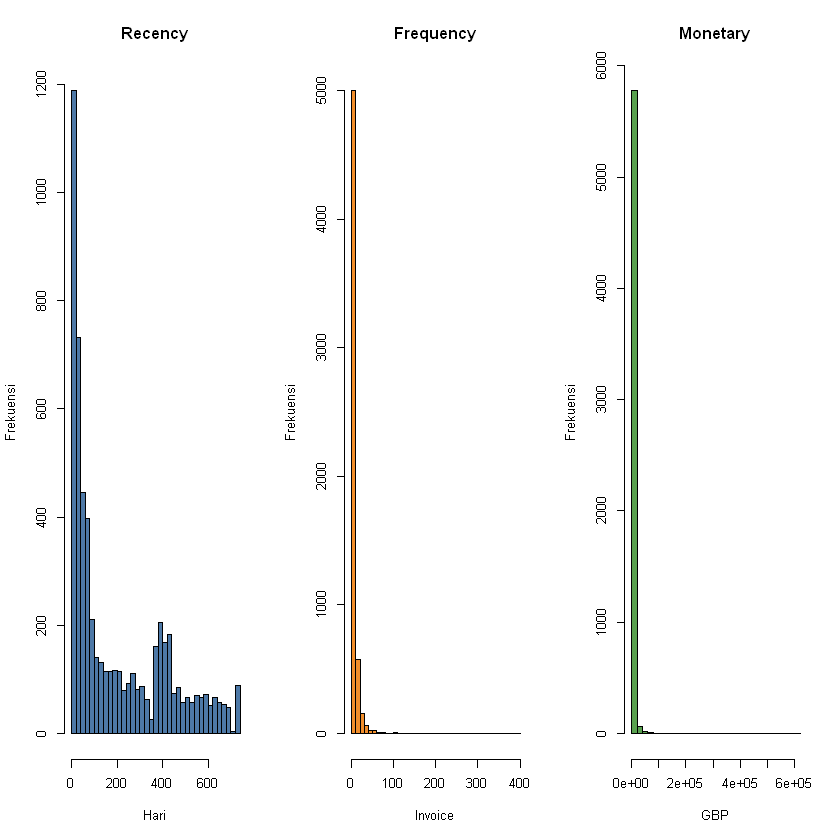

In [146]:
par(mfrow = c(1, 3))
hist(rfm$Recency,   breaks = 40, col = "#4E79A7", main = "Recency",
     xlab = "Hari", ylab = "Frekuensi")
hist(rfm$Frequency, breaks = 40, col = "#F28E2B", main = "Frequency",
     xlab = "Invoice", ylab = "Frekuensi")
hist(rfm$Monetary,  breaks = 40, col = "#59A14F", main = "Monetary",
     xlab = "GBP", ylab = "Frekuensi")
par(mfrow = c(1, 1))

# Scaling

Karena nilai Monetary bisa ribuan kali lebih besar dari Recency, variabel perlu distandarisasi agar jarak antar-objek tidak didominasi satu fitur.

In [147]:
# Ganti bagian scaling dengan ini:
rfm_log <- rfm |>
  dplyr::select(Recency, Frequency, Monetary) |>
  mutate(
    Recency   = log1p(Recency),
    Frequency = log1p(Frequency),
    Monetary  = log1p(Monetary)
  )

rfm_scaled <- scale(rfm_log) |> as.data.frame()

# Penentuan Jumlah Cluster Optimal

## Elbow Method

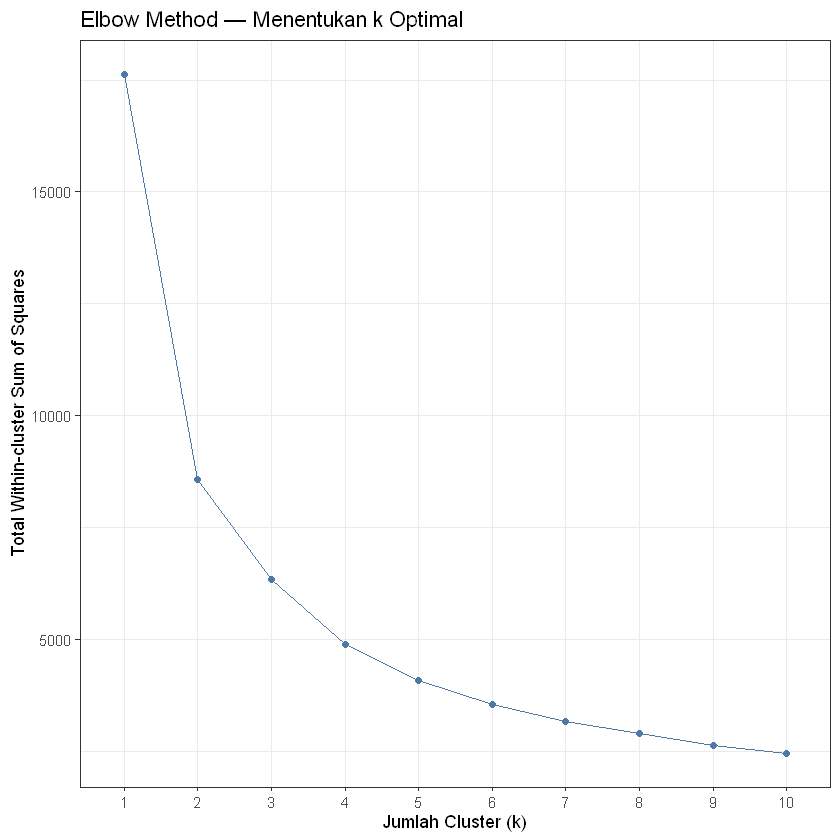

In [148]:
set.seed(16)
fviz_nbclust(rfm_scaled, kmeans,
             method = "wss",
             k.max  = 10,
             linecolor = "#4E79A7") +
  labs(title  = "Elbow Method — Menentukan k Optimal",
       x      = "Jumlah Cluster (k)",
       y      = "Total Within-cluster Sum of Squares") +
  theme_bw()

## Silhouette Method

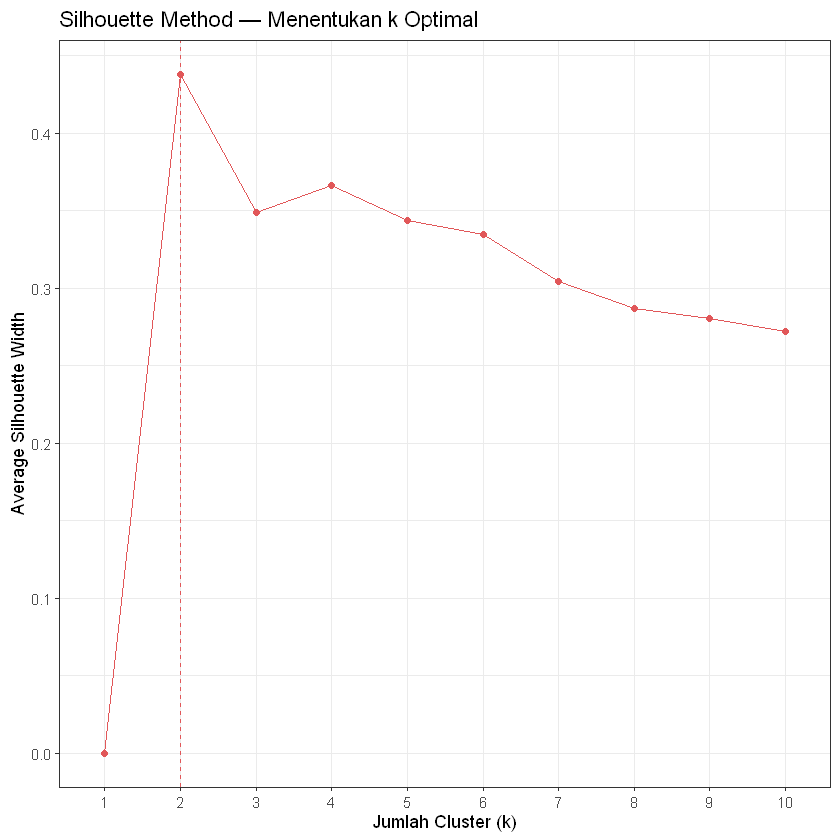

In [149]:
set.seed(16)
fviz_nbclust(rfm_scaled, kmeans,
             method = "silhouette",
             k.max  = 10,
             linecolor = "#E15759") +
  labs(title = "Silhouette Method — Menentukan k Optimal",
       x     = "Jumlah Cluster (k)",
       y     = "Average Silhouette Width") +
  theme_bw()

> **Kesimpulan:** Berdasarkan plot Silhouette, jumlah cluster optimal yang dipilih
> adalah **k = 2**. Nilai Silhouette tertinggi berada pada k = 2, sehingga pemisahan cluster paling baik secara statistik.

In [150]:
k_opt <- 2

# Metode Clustering 1: K-Means

K-Means adalah algoritma partisi yang meminimalkan jumlah kuadrat jarak
setiap titik ke centroid klusternya.

In [151]:
set.seed(16)
km_result <- kmeans(rfm_scaled, centers = k_opt, nstart = 25, iter.max = 300)

rfm$Cluster_KMeans <- as.factor(km_result$cluster)
cat("Ukuran tiap cluster K-Means:\n")
print(table(rfm$Cluster_KMeans))

Ukuran tiap cluster K-Means:

   1    2 
2357 3521 


## Visualisasi K-Means (PCA 2D)

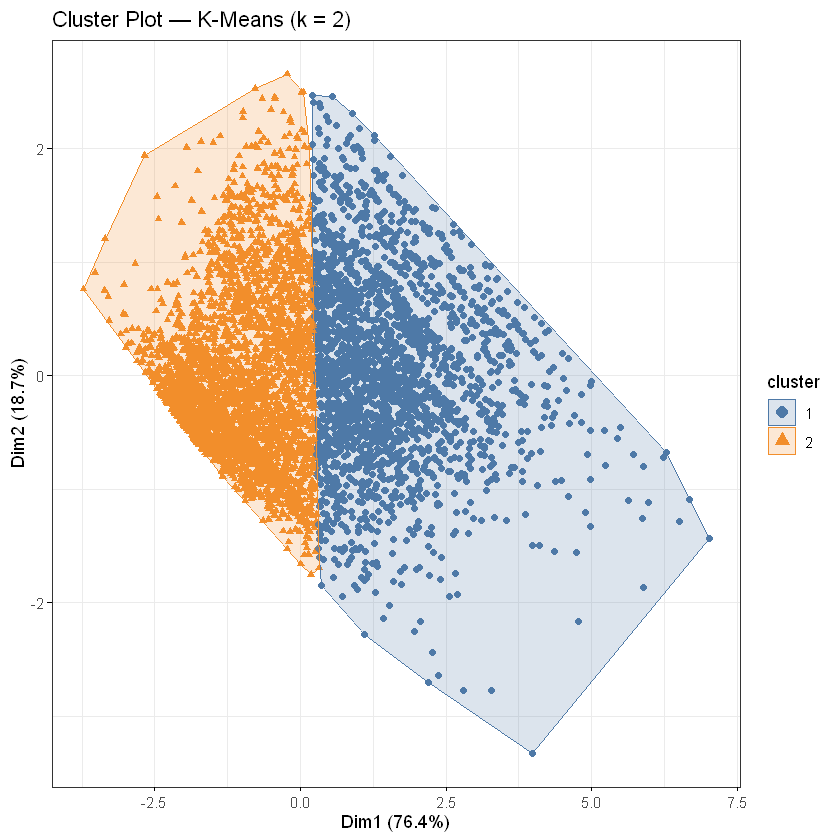

In [152]:
fviz_cluster(km_result, data = rfm_scaled,
             geom        = "point",
             ellipse.type= "convex",
             palette     = c("#4E79A7","#F28E2B"),
             ggtheme     = theme_bw(),
             main        = "Cluster Plot — K-Means (k = 2)") +
  theme(legend.position = "right")

# Metode Clustering 2: Gaussian Mixture Model (GMM)

GMM adalah pendekatan berbasis model yang mengasumsikan setiap cluster mengikuti distribusi Gaussian. Berbeda dengan K-Means, GMM memberikan **probabilitas keanggotaan** (soft assignment) dan mampu menangkap bentuk cluster yang lebih fleksibel melalui matriks kovarians.

In [153]:
set.seed(16)
gmm_result <- Mclust(rfm_scaled, G = k_opt, verbose = FALSE)

rfm$Cluster_GMM <- as.factor(gmm_result$classification)
cat("Model GMM terpilih:", gmm_result$modelName, "\n")
cat("Ukuran tiap cluster GMM:\n")
print(table(rfm$Cluster_GMM))

Model GMM terpilih: VVV 
Ukuran tiap cluster GMM:

   1    2 
1794 4084 


## Visualisasi GMM (BIC)

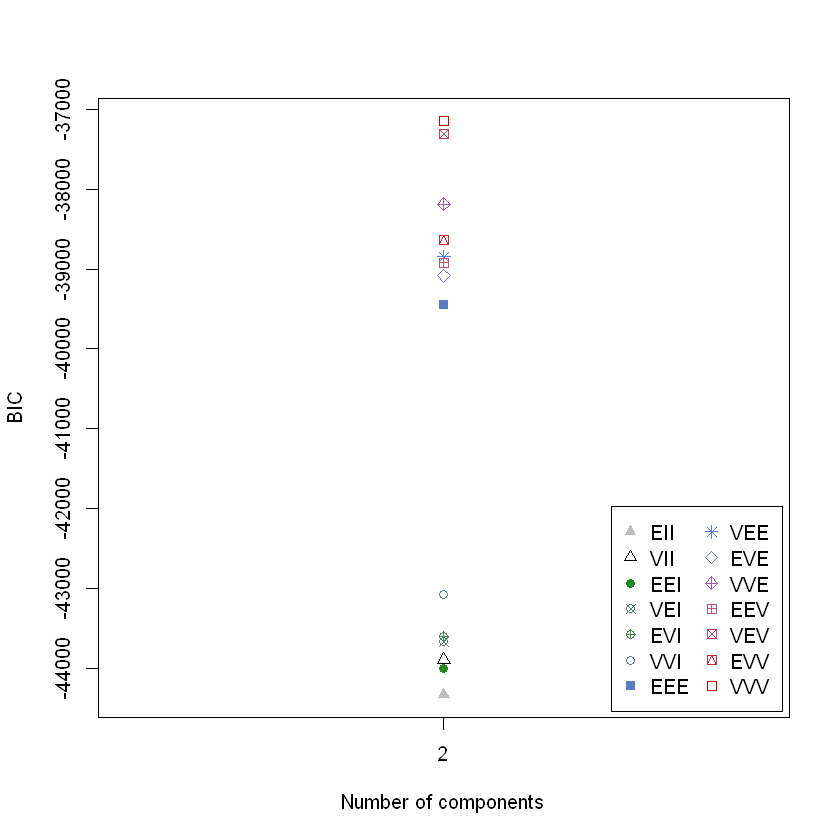

In [154]:
plot(gmm_result, what = "BIC",
     main = "BIC per Model GMM")

## Visualisasi GMM (Cluster Plot PCA 2D)

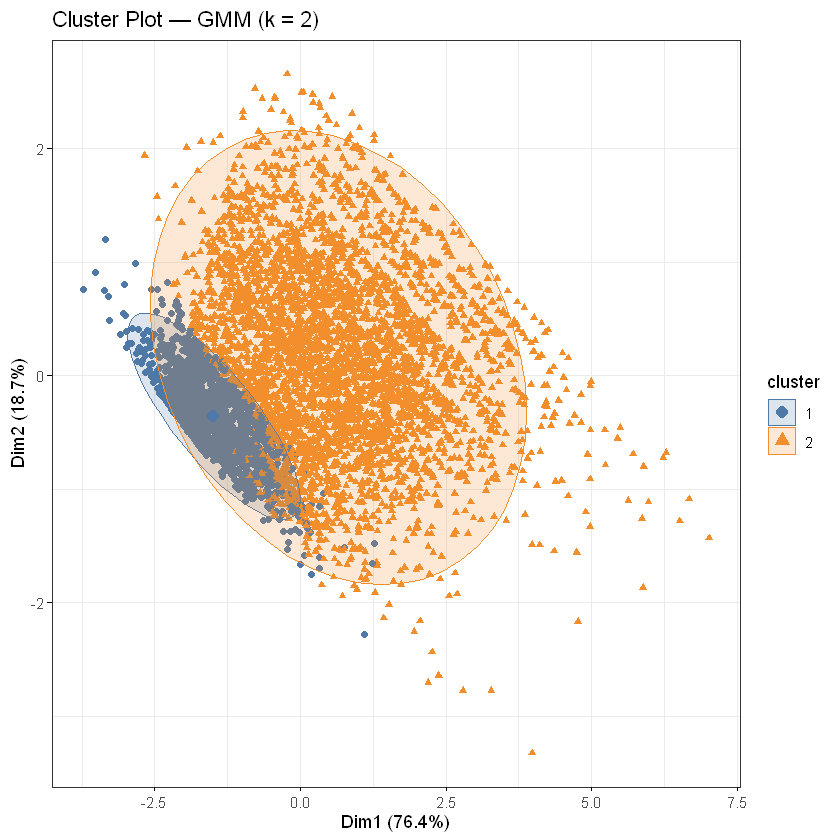

In [155]:
fviz_cluster(list(data    = rfm_scaled,
                  cluster = gmm_result$classification),
             geom        = "point",
             ellipse.type= "norm",
             palette     = c("#4E79A7","#F28E2B"),
             ggtheme     = theme_bw(),
             main        = "Cluster Plot — GMM (k = 2)") +
  theme(legend.position = "right")

# Validasi Cluster

Validasi menggunakan kriteria **internal** karena tidak ada label kelas yang diketahui (unsupervised).

## Silhouette Width

Mengukur seberapa mirip setiap objek dengan klusternya sendiri dibanding kluster lain. Nilai mendekati **1 = baik**.

In [156]:
dist_rfm <- dist(rfm_scaled)

sil_km  <- silhouette(km_result$cluster,  dist_rfm)
sil_gmm <- silhouette(gmm_result$classification, dist_rfm)

avg_sil_km  <- mean(sil_km[, "sil_width"])
avg_sil_gmm <- mean(sil_gmm[, "sil_width"])

cat("Rata-rata Silhouette K-Means :", round(avg_sil_km,  4), "\n")
cat("Rata-rata Silhouette GMM     :", round(avg_sil_gmm, 4), "\n")

Rata-rata Silhouette K-Means : 0.4381 
Rata-rata Silhouette GMM     : 0.2924 


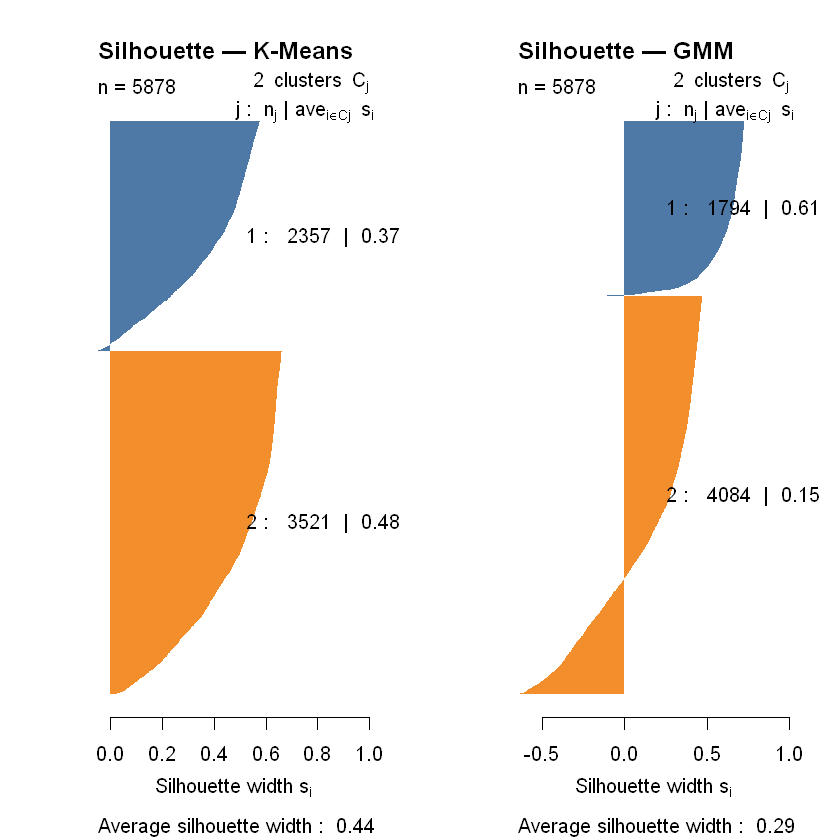

In [157]:
par(mfrow = c(1, 2))
plot(sil_km,  col = c("#4E79A7","#F28E2B"),
     border   = NA, main = "Silhouette — K-Means")
plot(sil_gmm, col = c("#4E79A7","#F28E2B"),
     border   = NA, main = "Silhouette — GMM")
par(mfrow = c(1, 1))

## Davies-Bouldin Index

Mengukur rata-rata rasio dispersi dalam kluster terhadap jarak antar kluster.
Nilai **lebih kecil = lebih baik**.

In [158]:
db_km  <- index.DB(rfm_scaled, km_result$cluster)$DB
db_gmm <- index.DB(rfm_scaled, gmm_result$classification)$DB

cat("Davies-Bouldin K-Means :", round(db_km,  4), "\n")
cat("Davies-Bouldin GMM     :", round(db_gmm, 4), "\n")

Davies-Bouldin K-Means : 0.9693 
Davies-Bouldin GMM     : 1.0982 


## Calinski-Harabasz Index

Rasio varians antar-kluster terhadap varians dalam-kluster.
Nilai **lebih besar = lebih baik**.

In [159]:
cat("Calinski-Harabasz K-Means :", round(stats_km$ch,  2), "\n")
cat("Calinski-Harabasz GMM     :", round(stats_gmm$ch, 2), "\n")

Calinski-Harabasz K-Means : 4393.74 
Calinski-Harabasz GMM     : 1123.55 


## Ringkasan Validasi

In [160]:
val_tbl <- data.frame(
  Metode              = c("K-Means", "GMM"),
  Silhouette          = round(c(avg_sil_km, avg_sil_gmm), 4),
  Davies.Bouldin      = round(c(db_km, db_gmm), 4),   # tambah ini
  Calinski.Harabasz   = round(c(stats_km$ch, stats_gmm$ch), 2)
)
knitr::kable(val_tbl, align = "lrr",
             caption = "Perbandingan Indeks Validasi Internal")



Table: Perbandingan Indeks Validasi Internal

|Metode  | Silhouette| Davies.Bouldin|Calinski.Harabasz |
|:-------|----------:|--------------:|:-----------------|
|K-Means |     0.4381|         0.9693|4393.74           |
|GMM     |     0.2924|         1.0982|1123.55           |

> **Interpretasi:** Metode dengan Silhouette lebih tinggi, Calinski-Harabasz lebih besar, dan Davies Bouldin lebih kecil dianggap menghasilkan cluster yang lebih kompak dan terpisah dengan baik.

---

# Profil Cluster

Cluster yang digunakan untuk interpretasi adalah hasil metode terbaik berdasarkan validasi di atas. Di sini kita analisis profil RFM per cluster.

In [161]:
rfm$Cluster_Final <- rfm$Cluster_KMeans

profil <- rfm |>
  group_by(Cluster_Final) |>
  summarise(
    N         = n(),
    Recency   = round(mean(Recency),   1),
    Frequency = round(mean(Frequency), 1),
    Monetary  = round(mean(Monetary),  0)
  )

knitr::kable(profil, align = "lrrrr",
             format.args = list(big.mark = ","),
             caption     = "Profil Rata-rata RFM per Cluster")



Table: Profil Rata-rata RFM per Cluster

|Cluster_Final |     N| Recency| Frequency| Monetary|
|:-------------|-----:|-------:|---------:|--------:|
|1             | 2,357|    51.4|      12.6|    6,604|
|2             | 3,521|   302.6|       2.1|      619|

## Visualisasi Profil Radar / Bar

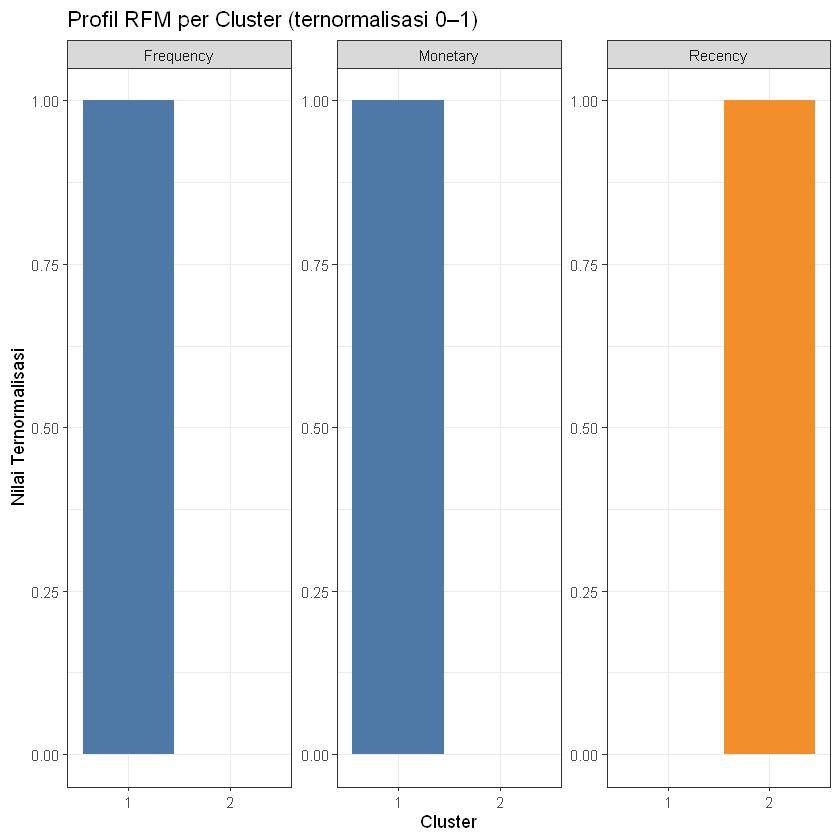

In [162]:
profil_long <- profil |>
  tidyr::pivot_longer(cols = c(Recency, Frequency, Monetary),
                      names_to  = "Metric",
                      values_to = "Value") |>
  # Normalisasi 0-1 per metrik untuk perbandingan
  group_by(Metric) |>
  mutate(ValueNorm = (Value - min(Value)) / (max(Value) - min(Value) + 1e-9)) |>
  ungroup()

ggplot(profil_long, aes(x = Cluster_Final, y = ValueNorm, fill = Cluster_Final)) +
  geom_col(show.legend = FALSE) +
  facet_wrap(~ Metric, scales = "free_y") +
  scale_fill_manual(values = c("#4E79A7","#F28E2B")) +
  labs(title = "Profil RFM per Cluster (ternormalisasi 0–1)",
       x     = "Cluster",
       y     = "Nilai Ternormalisasi") +
  theme_bw()

## Interpretasi Setiap Cluster

Berikut interpretasi bisnis berdasarkan rata-rata RFM untuk 2 cluster
berdasarkan output `profil`:

In [163]:
interp <- data.frame(
  Cluster    = c("1","2"),
  Segmen     = c("Pelanggan Aktif / Bernilai Tinggi",
                 "Pelanggan Tidak Aktif / Bernilai Rendah"),
  Deskripsi  = c(
    "Recency rendah, Frequency tinggi, dan Monetary tinggi; pelanggan masih aktif serta memberikan nilai transaksi besar.",
    "Recency tinggi, Frequency rendah, dan Monetary rendah; pelanggan cenderung tidak aktif dan kontribusi transaksi lebih kecil."
  ),
  Rekomendasi = c(
    "Pertahankan dengan program loyalitas, rekomendasi personal, dan penawaran eksklusif.",
    "Lakukan kampanye reaktivasi, diskon terbatas, dan reminder produk yang relevan."
  ),
  stringsAsFactors = FALSE
)
knitr::kable(interp, align = "llll",
             caption = "Interpretasi dan Rekomendasi Bisnis per Cluster")



Table: Interpretasi dan Rekomendasi Bisnis per Cluster

|Cluster |Segmen                                  |Deskripsi                                                                                                                    |Rekomendasi                                                                          |
|:-------|:---------------------------------------|:----------------------------------------------------------------------------------------------------------------------------|:------------------------------------------------------------------------------------|
|1       |Pelanggan Aktif / Bernilai Tinggi       |Recency rendah, Frequency tinggi, dan Monetary tinggi; pelanggan masih aktif serta memberikan nilai transaksi besar.         |Pertahankan dengan program loyalitas, rekomendasi personal, dan penawaran eksklusif. |
|2       |Pelanggan Tidak Aktif / Bernilai Rendah |Recency tinggi, Frequency rendah, dan Monetary rendah; pelanggan cenderung tidak aktif dan kontribu

> **Catatan:** Label segmen di atas bersifat indikatif. Sesuaikan dengan
> nilai aktual pada tabel `profil` yang muncul saat knit.